# Setup and Imports

In [1]:
 # Core
import importlib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerBase
import torch
import h5py
import lazy5
from lazy5.inspect import get_datasets, get_attrs_dset
from datetime import datetime
import matplotlib.patches as patches
import time
import sys
from pathlib import Path
import cascade

# Local modules
from cascade import dataset_utils, plot_utils
from cascade import tidytorch_utils as ttu


# Reload during active development
importlib.reload(dataset_utils)
importlib.reload(plot_utils)
importlib.reload(ttu)

# Common imports
from cascade.dataset_utils import voigt_peak, load_h5_file, save_h5_file



from cascade.plot_utils import (
    plot_voigt_fit_res,
    init_plot_context,
)

from cascade.tidytorch_utils import (
    process_conv_deriv_fit,
    pseudo_voigt,
    denoise_spectrum,
    compute_wavelet_peak,
    precompute_lorentz4_wavelets,

)

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print("device:", device)



device: cuda


# Load Spectrum of Interest

In [2]:
now = datetime.now().strftime("%m%d%Y_%H:%M:%S")

# RAW_PATH = r"/mnt/c/Users/adiering3/Desktop/Misc Snowflakes/preprocessed_medfilter_snowflakemyoG_GFP_09_PROCESS_2026515_13_51_0_818558.h5"
RAW_PATH = "/home/adiering3/projects/ChiR2026/Test_experimental_data/Taylor_fluor_neurons/preprocessed_medfilter_shot-5.2_PROCESS_2025915_18_14_19_554016.h5"
raw_data, nrb, dark, attrs = load_h5_file(RAW_PATH)

file = "phantom_neuron_shot-5.2"
filename = os.path.join("{file}_{now}")
print(f"filename = {filename}")

#Get the wavenumber axis from the attributes
coeffs = attrs['Calib.a_vec']
attrs['Calib.n_pix']= 2304
n_pix = 2304
ctr = attrs['Calib.ctr_wl0']
probe = attrs['Calib.probe']
probe *= 1e-7
converted_nm = np.polyval(coeffs, np.arange(n_pix))
converted_nm *= 0.0000001
wn = 1/converted_nm - 1/probe

Available datasets: ['/preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG']
Data   loaded from: /preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG  shape: (385, 500, 2304)
NRB not found — using ones  shape: (2304,)
Dark not found — dark=None
Attrs  loaded from: /preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG
filename = {file}_{now}


In [3]:
First_Run = True # whether this is the first run of the batch fitting loop (used to control aggressive optimization parameters)

In [4]:
# Select a pixel to visualize and test the fitting on
pixx= 100
pixy= 300

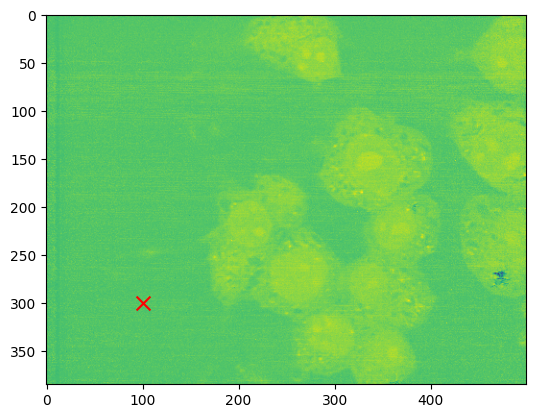

In [5]:
# Visualize the data
plt.imshow(np.imag(raw_data[:,:,860]))
plt.scatter(pixx, pixy, color='red', s=100, marker='x') 
plt.show()

/home/adiering3/projects/ChiR-Extraction/jaxenv2/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/adiering3/projects/ChiR-Extraction/jaxenv2/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


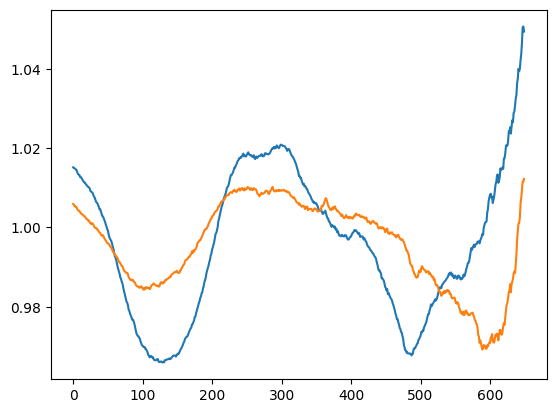

In [6]:
plt.plot(raw_data[100,300,550:1200])
plt.plot(raw_data[300, 100,550:1200])

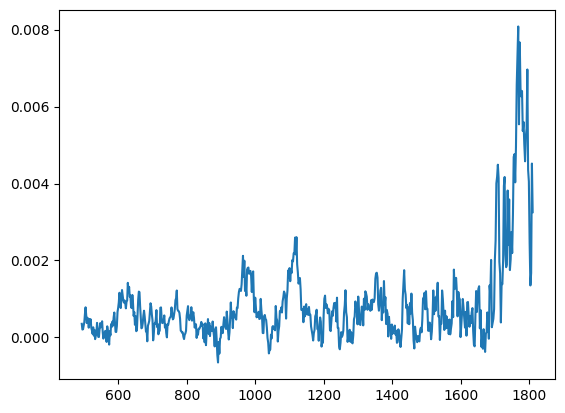

In [7]:
# crop your data to the fingerprint region, visualize and adjust as needed

crop_start = 550
crop_end = 1200
crop_wn= wn[crop_start:crop_end] ## Crop the wavenumber axis to match the data
wavenumbers= crop_wn

data = raw_data[:, :, crop_start:crop_end]
plt.plot(wavenumbers,np.imag(data[pixx, pixy,:]))  # Choose a pixel with good intensity to plot

In [8]:
del raw_data

# Fitting Parameters and Pre-computes

In [9]:
# These parameters probably won't need to be updated

spectrum = np.imag(data[pixx, pixy, :])

x = wavenumbers.copy()
x = x.astype(np.float32)

dx = (x[-1] - x[0]) / (len(x) - 1)  # cm⁻¹ per pixel
widths = np.linspace(1, 10, 100) * dx  # or just set directly in cm⁻¹

sigmas = torch.as_tensor(widths, dtype=torch.float32)
gammas = torch.tensor([1.0], dtype=torch.float32)
x_gpu  = torch.as_tensor(x, dtype=torch.float32)

x_c  = x_gpu - x_gpu.mean()

sigs = sigmas.view(-1, 1, 1)
gams = gammas.view( 1,-1, 1)
x_bc = x_c.view(   1, 1,-1)

# profiles = pseudo_voigt(x_bc, sigs, gams)
# max_vals = profiles.amax(dim=-1, keepdim=True)
# # wavelet_peaks_cached = profiles / (max_vals + 1e-12) 
# wavelet_peaks_cached = wavelet_peaks_cached.to(device)

# ── Precomputed constants (shared across all sweep calls) ─────────────────────
_x_dev     = x_gpu.to(device)
# _lor4_bank = precompute_lorentz4_wavelets(sigmas.to(device), _x_dev)  # (n_widths, n_pts)

_sigma_t = torch.tensor(3.0,  dtype=torch.float32, device=device)
_gamma_t = torch.tensor(1e-6, dtype=torch.float32, device=device)
_kernel  = compute_wavelet_peak(_sigma_t, _gamma_t, _x_dev)
_kernel  = _kernel / _kernel.sum()
_ker_fft = torch.fft.fft(torch.fft.ifftshift(_kernel))  # (n_pts,)

# Param bounds tensors (reused each step)
_LO = torch.tensor([0.0,    0.0, 0.05, 0.05], device=device)
_HI = torch.tensor([1.0, 4000.0, 50.0, 50.0], device=device)

# print(f"Wavelet bank : {_lor4_bank.shape}  on {_lor4_bank.device}")
print(f"Denoise kern : {_ker_fft.shape}    on {_ker_fft.device}")



Denoise kern : torch.Size([650])    on cuda:0


In [44]:
#Modify the parameters as needed:

adj = 0.0002 # if the spectrum goes below zero, add a small constant to the denoised spectrum to ensure positivity and good fits
response_threshold=0.0001 # CWT response threshold: adjust up for more selective peak detection, down for more peaks (but more false positives)
amp_threshold = 1e-6 # minimum amplitude threshold for detected peaks: adjust up to filter out small peaks, down to include more (but more false positives)
min_scale_votes=3 # minimum number of wavelet scales that must vote for a peak to be included in the initial fit (adjust up for more selectivity, down for more peaks but more false positives)
min_spacing_in=5.0 # minimum spacing between detected peaks in wavenumber units: Should be the instrument resolution... adjust up to prevent closely spaced peaks (but may miss real peaks that are close together), adjust down to allow more closely spaced peaks (but may result in multiple peaks fitting the same feature)  
min_spacing_post = 7.0 #minimum spacing between peaks after fitting - removes peaks that are stacked on top of each other
max_iter=5000  # maximum number of iterations for the fitting optimization: adjust up if fits aren't converging, down to save time (but may result in some fits not fully converging)
tol=1e-5 # convergence tolerance for the fitting optimization: adjust down for more precise fits (but may take longer to converge), adjust up to allow faster fits (but may be less precise)
scale_preference_fraction=0.7 # Scale preference fraction: between 0 and 1, this prevents the broadest wavlet response from dominanting the initial guesses - adjust down for narrow peaks, up for broad peaks


# Quick Convolution Denoise

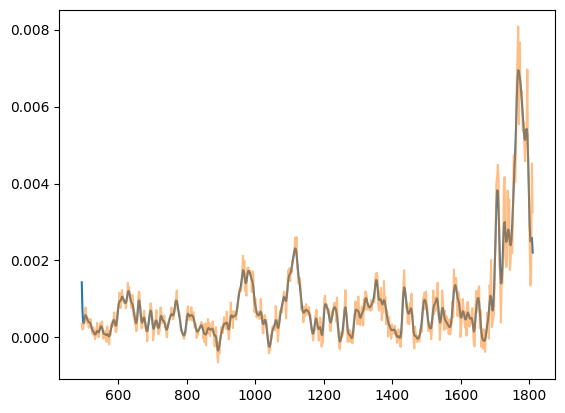

In [11]:
if First_Run:
    spectrum_denoised = denoise_spectrum(
        torch.as_tensor(spectrum, dtype=torch.float32),
        x_gpu,
        sigma=3.0,   # wavenumber units — start at ~half your narrowest peak width
        gamma=0.0,   # pure Gaussian → minimal ringing
    )
    plt.plot(x, spectrum_denoised.numpy(), label='Denoised Spectrum')
    plt.plot(x, spectrum, alpha=0.5, label='Original Spectrum')


# Run the Fitting for one Pixel

In [66]:
if First_Run:
    params_cd, converged_cd, n_iter_cd, response_tensor_cd, peak_mask_cd, p0_cd = process_conv_deriv_fit(spectrum_denoised + adj,x,sigmas=sigmas,gammas=gammas,response_threshold=response_threshold, amp_threshold = amp_threshold, min_scale_votes= min_scale_votes, min_spacing_in= min_spacing_in, min_spacing_post = min_spacing_post, max_iter=max_iter,  tol=tol, scale_preference_fraction=scale_preference_fraction, )

    print(f"converged: {converged_cd}  n_iter: {n_iter_cd}")
    print(f"peaks detected (mask): {peak_mask_cd.sum().item()}")
    print(f"non-zero fitted peaks: {(params_cd.reshape(-1,4)[:,0] > 1e-3).sum().item()}")


converged: True  n_iter: 2551
peaks detected (mask): 146
non-zero fitted peaks: 21


y_peaks shape: (59, 650)
RMSE: 0.0007   R²: 0.6111


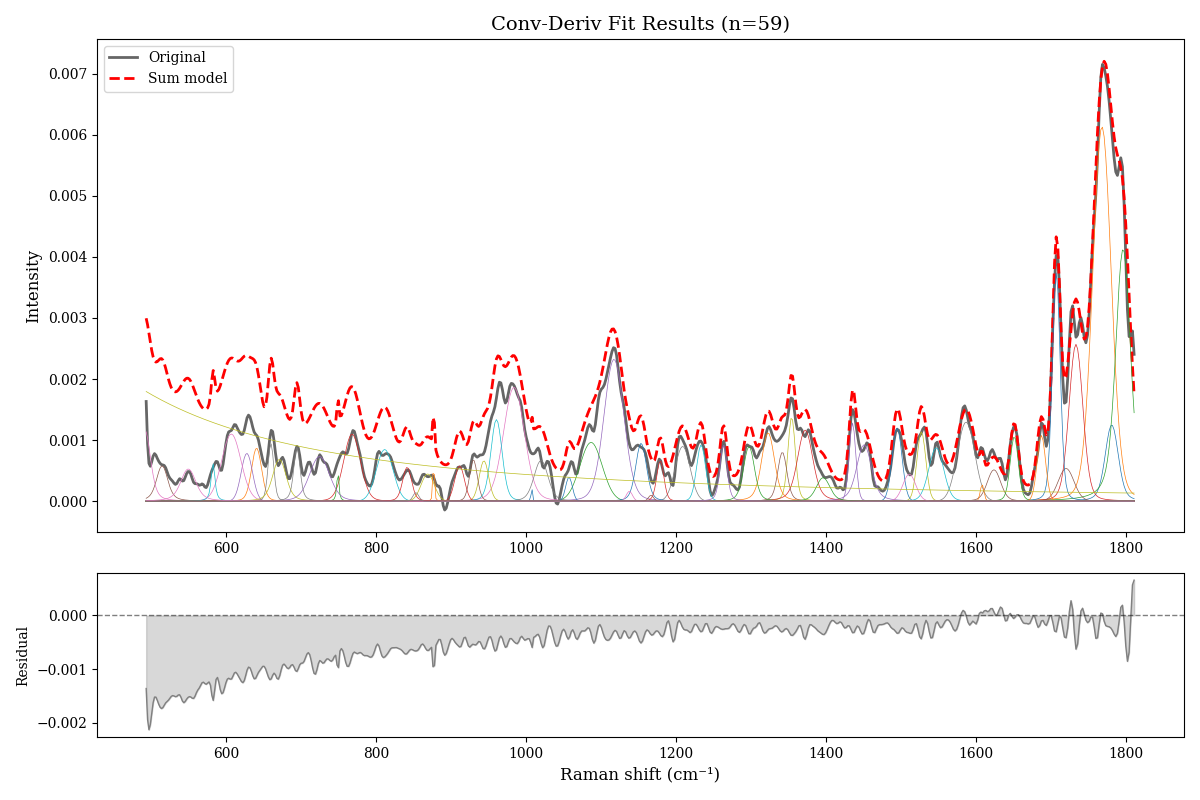

In [67]:
# Visualize the fit results - adjust the parameters above as needed to get good fits to the data
if First_Run:
    plot_voigt_fit_res(x, spectrum_denoised+ adj, params_cd, title="Conv-Deriv Fit Results")

# Run the Fitting for a batch

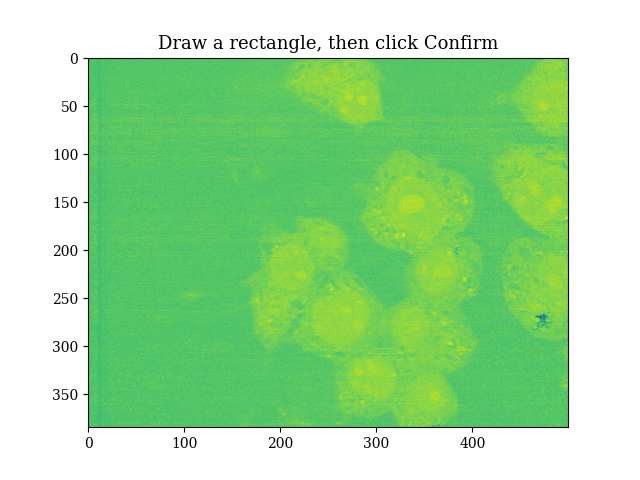

In [75]:
%matplotlib ipympl

from matplotlib.widgets import RectangleSelector
import ipywidgets as widgets
from IPython.display import display

fig, ax = plt.subplots()
ax.imshow(np.imag(data[:, :, 310]))
ax.set_title("Draw a rectangle, then click Confirm")

_roi = {}

def _on_select(eclick, erelease):
    _roi['X0'] = int(min(eclick.xdata, erelease.xdata))
    _roi['X1'] = int(max(eclick.xdata, erelease.xdata))
    _roi['Y0'] = int(min(eclick.ydata, erelease.ydata))
    _roi['Y1'] = int(max(eclick.ydata, erelease.ydata))

rs = RectangleSelector(ax, _on_select, useblit=True, button=[1],
                       interactive=True)

btn = widgets.Button(description="Confirm ROI", button_style='success')
lbl = widgets.Label()

def _confirm(_):
    if _roi:
        X0, X1, Y0, Y1 = _roi['X0'], _roi['X1'], _roi['Y0'], _roi['Y1']
        lbl.value = f"✓  X=[{X0}:{X1}]  Y=[{Y0}:{Y1}]  ({(X1-X0)*(Y1-Y0)} px)"
    else:
        lbl.value = "No selection yet — draw a rectangle first"

btn.on_click(_confirm)
display(widgets.HBox([btn, lbl]))
plt.show()


In [15]:
X0, X1=0, 425
Y0, Y1= 36, 537


In [76]:
if First_Run:
    X0, X1 = _roi['X0'], _roi['X1']
    Y0, Y1 = _roi['Y0'], _roi['Y1']
else: 
    X0, X1=0, 425
    Y0, Y1= 36, 537

data_crop = np.imag(data[Y0:Y1, X0:X1, :]).astype(np.float32)
spectra_np_batch = data_crop.reshape(-1, data_crop.shape[-1])
print(f"ROI: {data_crop.shape}  →  batch: {spectra_np_batch.shape}")


ROI: (289, 253, 650)  →  batch: (73117, 650)


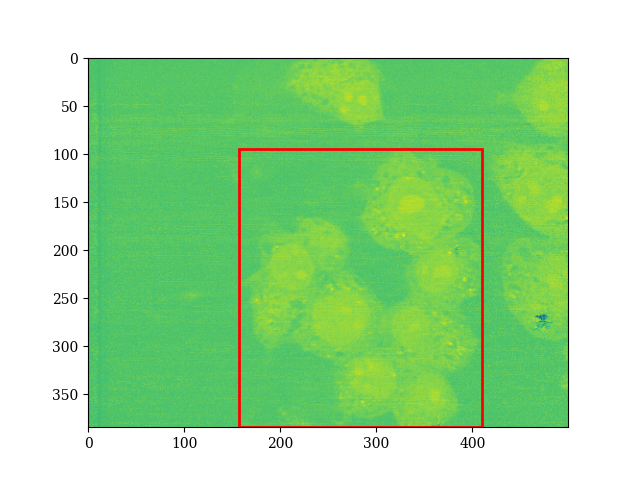

In [77]:
# # ── ROI selection ────────────────────────────────────────────────────────────
# X0, X1 = 260, 310  # x pixel range (columns)
# Y0, Y1 = 310, 380  # y pixel range (rows)

fig, ax = plt.subplots()
ax.imshow(np.imag(data[:, :, 310]))
rect = patches.Rectangle((X0, Y0), X1-X0, Y1-Y0, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.show()

# ── Batch fitting parameters ──────────────────────────────────────────────────
BATCH_SIZE          = 1000    # spectra per GPU batch; lower if you get OOM errors
MAX_ITER_BATCH      = max_iter
TOL_BATCH           = tol
AMP_THR_BATCH       = amp_threshold
MIN_SPACING_IN_BATCH  = min_spacing_in
MIN_SPACING_POST_BATCH = min_spacing_post
RESPONSE_THRESHOLD  = response_threshold
MIN_SCALE_VOTES     = min_scale_votes
MAX_PEAKS_BATCH     = 200

# Aggressive-start Adam controls
AGGR_STEPS  = 80    # aggressive burst steps at the start of optimisation
AGGR_LR_MULT = 4.0  # LR multiplier during burst
AGGR_CLIP   = 3.0   # gradient clip norm during burst
AGGR_BETA1  = 0.85  # Adam beta1 during burst

# Progress-print cadences
CHECKPOINT_EVERY     = 5000  # spectra between p0-build progress prints
FIT_CHECKPOINT_EVERY = 250   # Adam iterations between fit progress prints

In [78]:
# Extract ROI — take imaginary part of complex BCARS data and flatten to (N, n_pts)
data_crop = np.imag(data[Y0:Y1, X0:X1, :]).astype(np.float32)
spectra_np_batch = data_crop.reshape(-1, data_crop.shape[-1])
print(f"ROI: {data_crop.shape}  →  batch: {spectra_np_batch.shape}")

ROI: (289, 253, 650)  →  batch: (73117, 650)


In [79]:
if First_Run:
    name = f'snowflakemyoG_GFP_09_{datetime.now().strftime('%Y%m%d')}_{len(spectra_np_batch)}xsamples_tol={TOL_BATCH}'

else: 
    name = "snowflakemyoG_GFP_09_20260515_212925xsamples_tol=1e-05" # adjust to match the filename of your saved results if not the first run
print(name)

snowflakemyoG_GFP_09_20260528_73117xsamples_tol=1e-05


In [80]:
if First_Run:
    RESUME = False
else:
    RESUME = True  # set to True to resume from an existing checkpoint

In [ ]:
importlib.reload(ttu)
ttu.init_sweep_context(x_gpu, sigmas, gammas, device, widths)
init_plot_context(x, widths)

results = ttu.run_batch_fit(
    spectra_np_batch,
    name=name,
    batch_size=BATCH_SIZE,
    max_iter=2000,
    tol=1e-5,
    amp_threshold=AMP_THR_BATCH,
    min_spacing_in=MIN_SPACING_IN_BATCH,
    min_spacing_post=MIN_SPACING_POST_BATCH,
    response_threshold=RESPONSE_THRESHOLD,
    min_scale_votes=MIN_SCALE_VOTES,
    max_peaks=MAX_PEAKS_BATCH,
    scale_preference_fraction=scale_preference_fraction,
    aggr_steps=AGGR_STEPS,
    aggr_lr_mult=AGGR_LR_MULT,
    aggr_clip=AGGR_CLIP,
    aggr_beta1=AGGR_BETA1,
    checkpoint_every=CHECKPOINT_EVERY,
    fit_checkpoint_every=FIT_CHECKPOINT_EVERY,
    resume=RESUME,
)

params_all = results['params_all']
model_all  = results['model_all']
spec_d_all = results['spec_d']
x_np       = results['x_axis']

Sweep context initialised on cuda
  Wavelet bank : torch.Size([100, 650])
  Denoise kern : torch.Size([650])

[batch 0:1000] spectra: 1000 x 650
[p0] initialized 1000/1000 (100.0%) | elapsed 2.9s | ETA 0.0s
[fit] iter 250/2000 (12.5%) | loss/pix=1.0863e-01 | lr=9.96e-03 | elapsed 45.2s | ETA 316.6s
[fit] iter 500/2000 (25.0%) | loss/pix=8.6474e-02 | lr=9.26e-03 | elapsed 91.3s | ETA 273.9s
[fit] iter 750/2000 (37.5%) | loss/pix=7.3462e-02 | lr=7.78e-03 | elapsed 139.2s | ETA 232.0s
[fit] iter 1000/2000 (50.0%) | loss/pix=6.5215e-02 | lr=5.79e-03 | elapsed 184.5s | ETA 184.5s
[fit] iter 1250/2000 (62.5%) | loss/pix=6.0722e-02 | lr=3.65e-03 | elapsed 236.9s | ETA 142.1s
[fit] iter 1500/2000 (75.0%) | loss/pix=5.8366e-02 | lr=1.76e-03 | elapsed 288.7s | ETA 96.2s
[fit] iter 1750/2000 (87.5%) | loss/pix=5.7420e-02 | lr=4.72e-04 | elapsed 350.9s | ETA 50.1s
[fit] iter 2000/2000 (100.0%) | loss/pix=5.7274e-02 | lr=1.00e-05 | elapsed 414.1s | ETA 0.0s

Batch fit summary:
  total  : 418.033s  

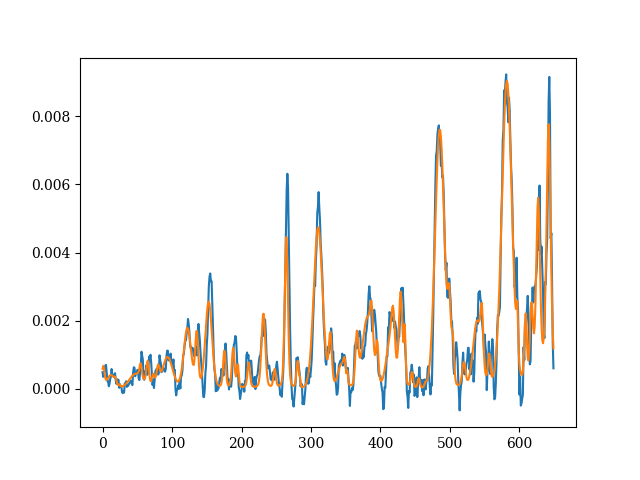

In [74]:
# Reshape flat results back to spatial grid and save
H, W = Y1 - Y0, X1 - X0
params_cube = params_all.reshape(H, W, -1)
model_cube  = model_all.reshape(H, W, -1)
spec_d_cube = spec_d_all.reshape(H, W, -1)
plt.close('all')
plt.plot(data_crop[15, 15, :])
plt.plot(model_cube[15, 15, :])
plt.show()

In [ ]:

save_h5_file(
    f"fitted_{name}.h5",
    SAVE_FOLDER=".",
    attrs=attrs, data=data_crop, nrb=nrb, dark=dark,
    model=model_cube,
    peak_params=params_cube,
    x_axis=x_np,
)
print(f"Saved: fitted_{name}.h5")

In [ ]:
import sys

# See all large variables in the notebook
for name, obj in sorted(globals().items(), key=lambda x: sys.getsizeof(x[1]), reverse=True)[:20]:
    print(f"{sys.getsizeof(obj)/1e6:.1f} MB  {name}")

553.6 MB  data_crop
0.0 MB  nrb
0.0 MB  converted_nm
0.0 MB  wn
0.0 MB  _i7
0.0 MB  attrs
0.0 MB  _i18
0.0 MB  _i12
0.0 MB  x
0.0 MB  x_np
0.0 MB  _i8
0.0 MB  HandlerBase
0.0 MB  RectangleSelector
0.0 MB  _i9
0.0 MB  _i1
0.0 MB  _i17
0.0 MB  _i15
0.0 MB  _i14
0.0 MB  Path
0.0 MB  obj


In [ ]:
for name, obj in globals().items():
    if isinstance(obj, torch.Tensor):
        print(f"{obj.element_size() * obj.nelement() / 1e6:.1f} MB  {name}  {obj.shape}")
    elif isinstance(obj, __import__('numpy').ndarray):
        print(f"{obj.nbytes / 1e6:.1f} MB  {name}  {obj.shape}")

0.0 MB  nrb  (2304,)
0.0 MB  coeffs  (2,)
0.0 MB  converted_nm  (2304,)
0.0 MB  wn  (2304,)
0.0 MB  crop_wn  (650,)
0.0 MB  wavenumbers  (650,)
0.0 MB  spectrum  (650,)
0.0 MB  x  (650,)
0.0 MB  widths  (100,)
0.0 MB  sigmas  torch.Size([100])
0.0 MB  gammas  torch.Size([1])
0.0 MB  x_gpu  torch.Size([650])
0.0 MB  x_c  torch.Size([650])
0.0 MB  sigs  torch.Size([100, 1, 1])
0.0 MB  gams  torch.Size([1, 1, 1])
0.0 MB  x_bc  torch.Size([1, 1, 650])
0.0 MB  _x_dev  torch.Size([650])
0.0 MB  _sigma_t  torch.Size([])
0.0 MB  _gamma_t  torch.Size([])
0.0 MB  _kernel  torch.Size([650])
0.0 MB  _ker_fft  torch.Size([650])
0.0 MB  _LO  torch.Size([4])
0.0 MB  _HI  torch.Size([4])
0.0 MB  spectrum_denoised  torch.Size([650])
0.0 MB  params_cd  torch.Size([800])
0.3 MB  response_tensor_cd  torch.Size([100, 1, 650])
0.0 MB  peak_mask_cd  torch.Size([650])
0.0 MB  p0_cd  torch.Size([800])
0.0 MB  x_np  (650,)
681.4 MB  params_cube  torch.Size([501, 425, 800])
553.6 MB  model_cube  torch.Size([501,

In [ ]:
import gc, torch

del data          # 2.8 GB  — raw data, already processed
del data_crop     # 0.5 GB  — cropped version, already used
del spectra_np_batch  # 0.5 GB  — flat input, already fitted

# flat arrays — same data as the cubes, pick one or the other
del params_all, model_all, spec_d_all  # 1.8 GB

# or if you're done with the cubes instead
# del params_cube, model_cube, spec_d_cube

gc.collect()
torch.cuda.empty_cache()

In [ ]:
plt.imshow(model_cube[:,:,310])
plt.show()
plt.imshow(spec_d_cube[:,:,310])
plt.show()
plt.imshow(np.real(data_crop[:,:,310]))
plt.show()

In [ ]:
# Visualize and Compare the original data and the fitted model for a specific spectral index (channel) across the ROI.

SPEC_IDX = 300  # spectral index to display — change to any channel of interest

orig_slice  = np.imag(data[X0:X1, Y0:Y1, SPEC_IDX])
model_slice = model_roi[:, :, SPEC_IDX]

vmin = orig_slice.min()
vmax = orig_slice.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(orig_slice,  origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title(f'Original data  (channel {SPEC_IDX})')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(model_slice, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title(f'Fitted model   (channel {SPEC_IDX})')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()